# 1. Setup & Mount Google Drive
Run this cell to import necessary libraries and mount your Google Drive (Google Colab only).

In [14]:
from google.colab import drive
import os
import sys

print("Mounting Google Drive...")
drive.mount('/content/drive')

# UPDATE THIS PATH to where you uploaded the project in your Drive
PROJECT_PATH = '/content/drive/MyDrive/cnn_image_classifier'
os.chdir(PROJECT_PATH)

# Add src folder to path so we can import our scripts natively
sys.path.append(os.path.join(PROJECT_PATH, 'src'))
print(f"Working directory: {os.getcwd()}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/cnn_image_classifier


# 2. Load and Split Data
Imports `load_data` from `src/data_loader.py`.

> **Note:** `load_data()` now returns **three** splits:
> - `(x_train, y_train)` — 90% of original training set, used for model.fit
> - `(x_val, y_val)`   — 10% of original training set, used as validation_data
> - `(x_test, y_test)` — original test set, **only touched during final evaluation**
>
> Previously `validation_data=(x_test, y_test)` was passed to `model.fit()`, which
> caused test-set leakage — callbacks were tuning decisions against the test set.

In [15]:
from data_loader import load_data

(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data()
print(f"Train : {x_train.shape}")
print(f"Val   : {x_val.shape}")
print(f"Test  : {x_test.shape}")

Loading CIFAR-10 dataset...
  Train : 45000 samples
  Val   : 5000 samples  (held-out from train, never seen by test)
  Test  : 10000 samples  (untouched)
Train : (45000, 32, 32, 3)
Val   : (5000, 32, 32, 3)
Test  : (10000, 32, 32, 3)


# 3. Data Visualization
A sample of 10 images from the CIFAR-10 training set.

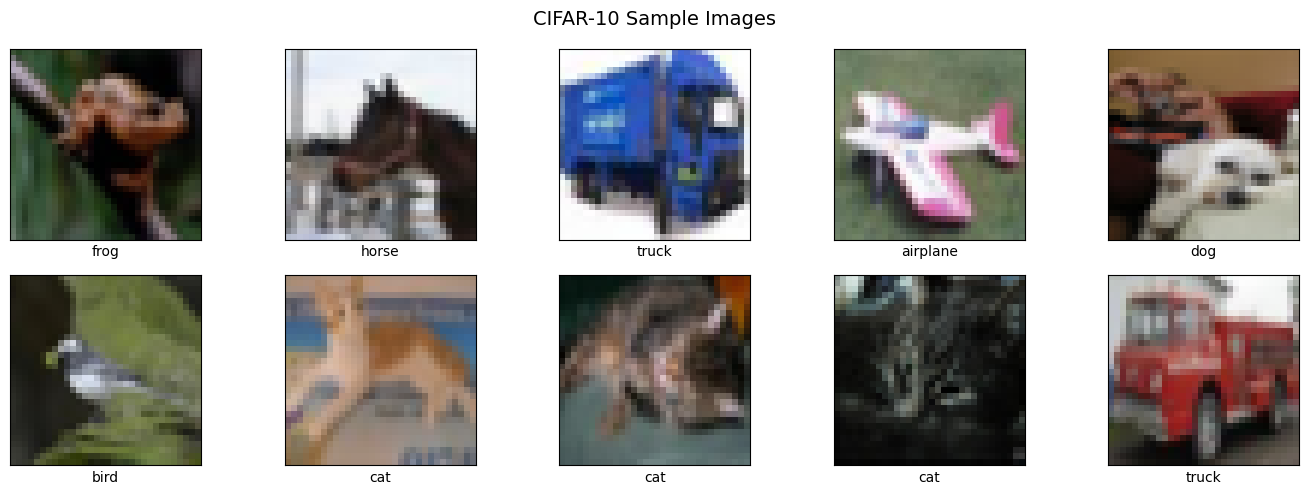

In [16]:
import matplotlib.pyplot as plt
from config import CLASSES

plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(CLASSES[y_train[i][0]])
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Initialize Model
Imports the CNN architecture from `src/model.py`.

> **Fix:** Dense head was `Flatten(2048) → Dense(128)` — a 16x compression bottleneck.
> Now `Flatten(2048) → Dense(512) → Dense(256)` for a proportional reduction.

In [17]:
from model import create_model

model = create_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,474,858 (5.63 MB)

 Trainable params: 1,472,426 (5.62 MB)

 Non-trainable params: 2,432 (9.50 KB)

# 5. Training
Trains with data augmentation, a proper validation split, and aligned callbacks.

> **Fixes applied:**
> 1. `EarlyStopping` and `ModelCheckpoint` now both monitor `val_accuracy` (was split across `val_loss` / `val_accuracy`).
> 2. `validation_data=(x_val, y_val)` — clean val split, not the test set.
> 3. `epochs=75` with `patience=10` — previously `epochs=15, patience=4` cut training too early on augmented data.
> 4. On-the-fly augmentation via `get_augmented_generator` (expected +5-8% accuracy).
> 5. `ReduceLROnPlateau` added to squeeze gains after initial convergence.

In [18]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from data_loader import get_augmented_generator
from config import EPOCHS, PATIENCE, BATCH_SIZE, PATHS

os.makedirs(os.path.dirname(PATHS['model']), exist_ok=True)

# FIX: all callbacks monitor the same metric
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=PATHS['model'],
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
]

# Augmented generator — only training data is augmented, never val/test
train_generator  = get_augmented_generator(x_train, y_train)
steps_per_epoch  = len(x_train) // BATCH_SIZE

print(f"Starting training (max {EPOCHS} epochs, patience={PATIENCE})...")
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),   # FIX: was (x_test, y_test)
    callbacks=callbacks,
    verbose=1
)

Starting training (max 75 epochs, patience=10)...
Epoch 1/75
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2806 - loss: 2.2692
Epoch 1: val_accuracy improved from None to 0.49060, saving model to /content/drive/MyDrive/cnn_image_classifier/models/final_model/cifar10_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_image_classifier/models/final_model/cifar10_cnn_model.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.3612 - loss: 1.8690 - val_accuracy: 0.4906 - val_loss: 1.4018 - learning_rate: 0.0010
Epoch 2/75
  1/703 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.4844 - loss: 1.4577
Epoch 2: val_accuracy improved from 0.49060 to 0.49120, saving model to /content/drive/MyDrive/cnn_image_classifier/models/final_model/cifar10_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_image_classifier/models/final_model/cifar10_cnn_model.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4844 - loss: 1.457

# 6. Training Curves
Plotting accuracy and loss over epochs.

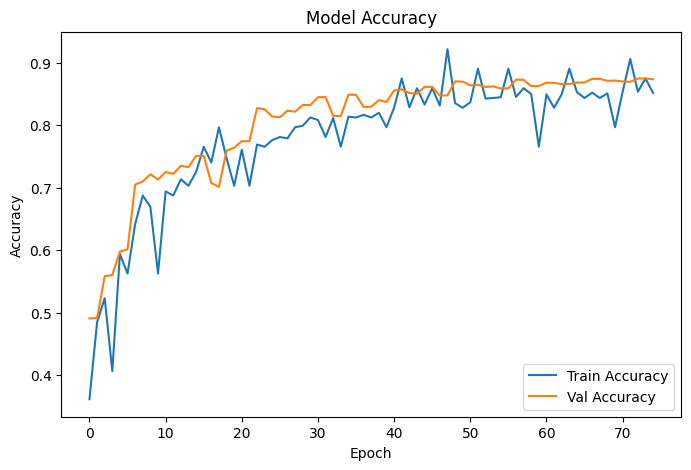

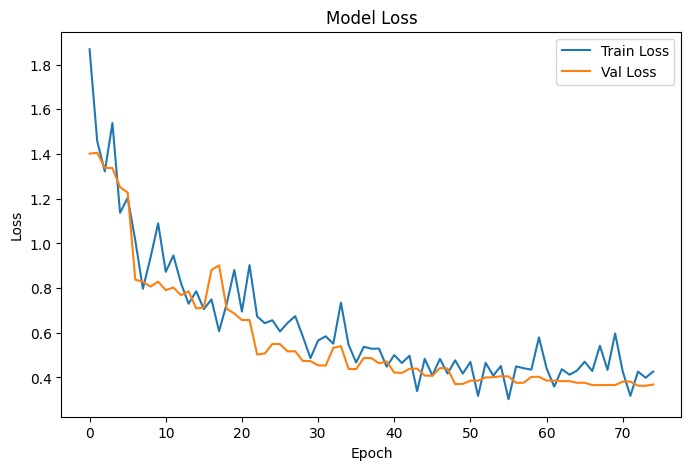

In [19]:
os.makedirs(PATHS['plots'], exist_ok=True)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.savefig(os.path.join(PATHS['plots'], 'accuracy.png'), dpi=150)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig(os.path.join(PATHS['plots'], 'loss.png'), dpi=150)
plt.show()

# 7. Final Evaluation on Test Set
Only now do we touch `x_test` — it was **never used** during training or callback decisions.

In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Evaluating on untouched test set...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

predictions    = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = y_test.flatten() if y_test.ndim > 1 else y_test

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

Evaluating on untouched test set...
Test Accuracy : 0.8598
Test Loss     : 0.4141

Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.88      0.88      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.88      0.76      0.82      1000
         cat       0.81      0.65      0.72      1000
        deer       0.85      0.84      0.84      1000
         dog       0.82      0.77      0.80      1000
        frog       0.73      0.97      0.84      1000
       horse       0.90      0.90      0.90      1000
        ship       0.93      0.94      0.94      1000
       truck       0.90      0.94      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



# 8. Confusion Matrix

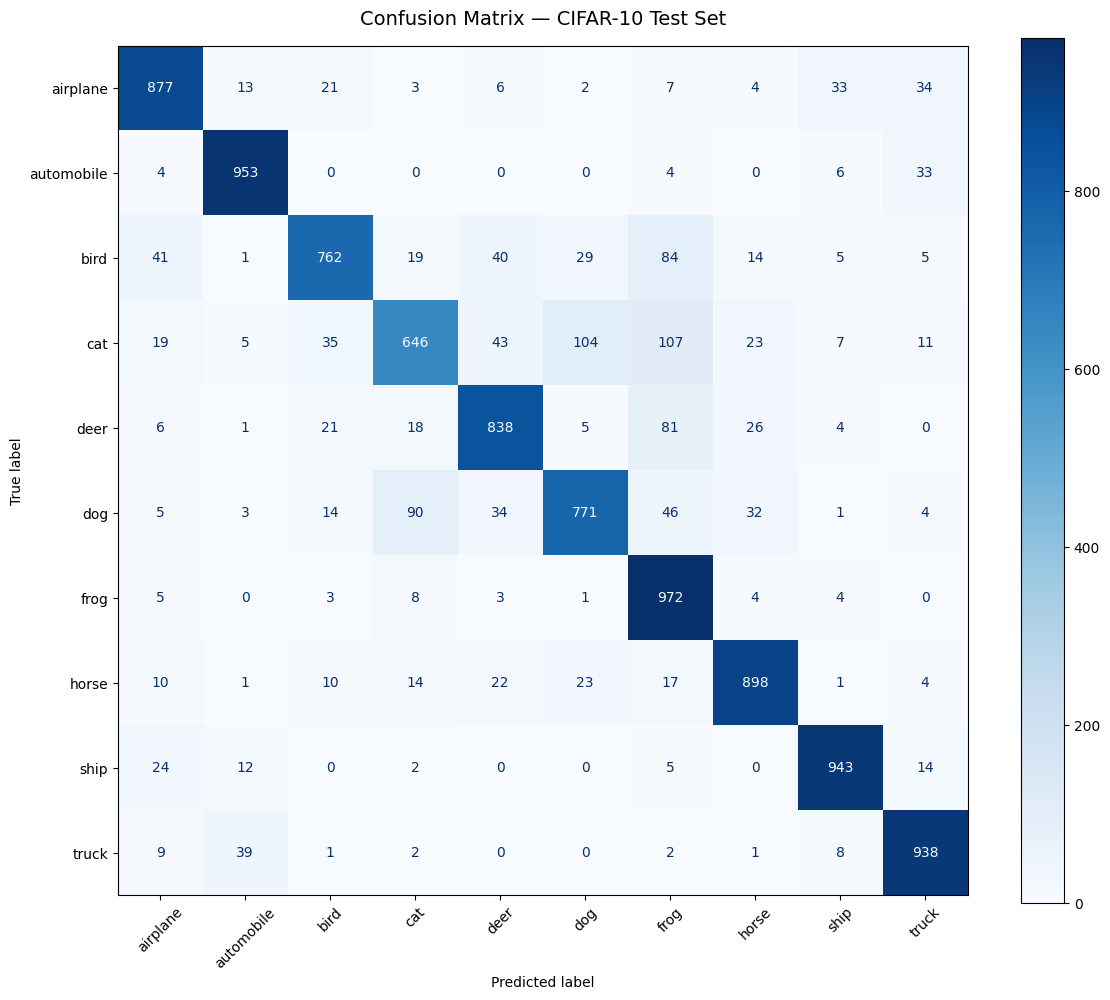

In [21]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — CIFAR-10 Test Set', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['plots'], 'confusion_matrix.png'), dpi=150)
plt.show()